In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

## [문제] 타이타닉 폴더에 있는 train.csv파일을 사용하여 아래 문제에 대한 답을 작성하시오.  
### <처리조건>  
### matplotlib 라이브러리를 사용한다.

In [4]:
df = pd.read_csv('./titanic/train.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


#### (1) Survived 컬럼의 생존자와 사망자 수를 구하여 막대 그래프로 나타내시오.

In [34]:
# 사망자
dead1 = df[df['Survived'] == 0].groupby('Survived').size()
dead1

Survived
0    549
dtype: int64

In [35]:
# 생존자
survived1 = df[df['Survived'] == 1].groupby('Survived').size()
survived1

Survived
1    342
dtype: int64

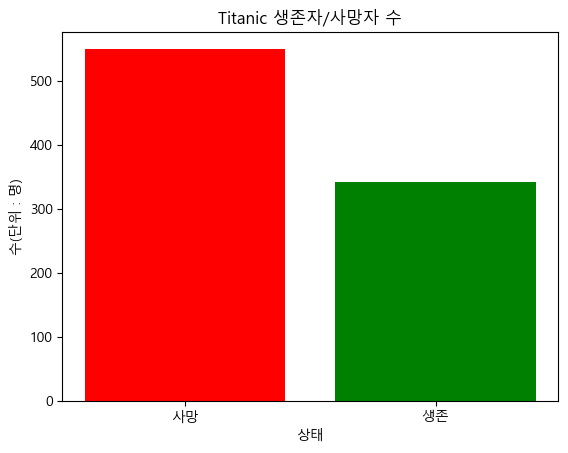

In [38]:
labels = ['사망', '생존']
values = [dead1.iloc[0], survived1.iloc[0]]
color = ['r', 'g']

plt.bar(labels, values, color=color)
plt.title('Titanic 생존자/사망자 수')
plt.xlabel('상태')
plt.ylabel('수(단위 : 명)')

plt.show()

#### (2) Survived 컬럼의 생존자와 사망자 수를 등급별로 구하여 누적막대그래프로 나타내시오. 등급을 누적으로 나타낸다.

In [51]:
# 사망자
dead2 = df[df['Survived']==0].groupby('Pclass')[['Survived']].count()
dead2

,Survived
Pclass,
1,80
2,97
3,372


In [52]:
# 생존자
survived2 = df[df['Survived']==1].groupby('Pclass')[['Survived']].count()
survived2

,Survived
Pclass,
1,136
2,87
3,119


In [84]:
# 사망자와 생존자 Series를 하나의 DataFrame으로 병합
result = pd.concat([dead2, survived2], axis=1)
result.columns = ['Dead', 'Survived']
result = result.T
result = result.reset_index()
result

Pclass,index,1,2,3
0,Dead,80,97,372
1,Survived,136,87,119


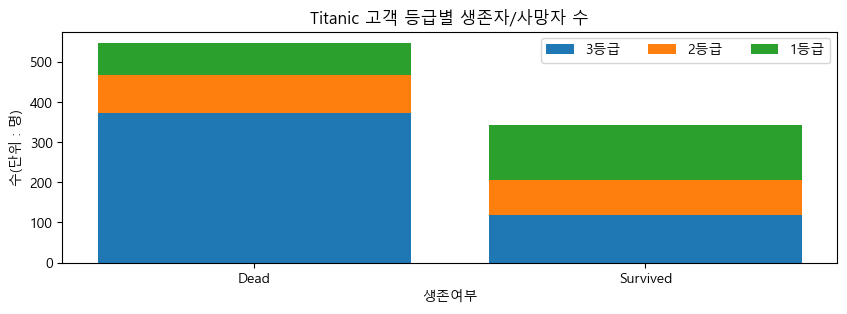

In [82]:
plt.figure(figsize = (10, 3))
plt.title('Titanic 고객 등급별 생존자/사망자 수')
plt.xlabel('생존여부')
plt.ylabel('수(단위 : 명)')

plt.bar(result['index'], result[3], label='3등급')
plt.bar(result['index'], result[2], bottom=result[3], label='2등급')
plt.bar(result['index'], result[1], bottom=result[3] + result[2], label='1등급')

plt.xticks(result['index'])

plt.legend(ncol=3)
plt.show()

#### (3) Embarked 컬럼의 탑승지역의 분포를 파이차트로 나타내는데 각 탑승지역에 해당하는 비율을 파이차트에 출력하시오.

In [64]:
region = df.groupby('Embarked').size()
region

Embarked
C    168
Q     77
S    644
dtype: int64

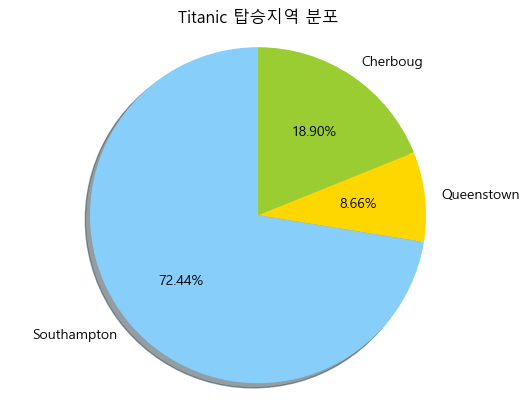

In [68]:
labels = ['Cherboug', 'Queenstown', 'Southampton']
values = region.values
color = ['yellowgreen', 'gold', 'lightskyblue']

plt.title('Titanic 탑승지역 분포')
plt.pie( values, labels=labels, colors=color, 
        autopct='%1.2f%%',
        shadow=True,
        startangle=90,
        counterclock=False)

plt.axis('equal')
plt.show()

#### (4) Age컬럼을 10대미만, 10대, 20대, 30대, 40대, 50대, 60대, 70대, 80대 구간으로 나누어 히스트그램을 나타내시오.

In [71]:
age = df['Age'].dropna()
age

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
885    39.0
886    27.0
887    19.0
889    26.0
890    32.0
Name: Age, Length: 714, dtype: float64

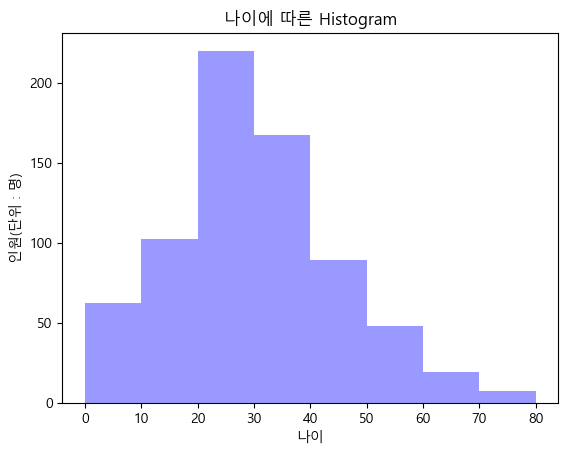

In [75]:
x = [0, 10, 20, 30, 40, 50, 60, 70, 80]

plt.hist(age, bins=x, rwidth=1, color = 'blue', alpha=0.4, density=False)
plt.title("나이에 따른 Histogram")
plt.xlabel("나이")
plt.ylabel("인원(단위 : 명)")

plt.show()